In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
zip_file_path = '/content/drive/MyDrive/Boston Housing Data.zip'

In [3]:
import zipfile
import os
extraction_dir = '/content/drive/MyDrive/Boston_Extracted_Data'
os.makedirs(extraction_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_dir)
    print(f"Files extracted to {extraction_dir}")
extracted_files = os.listdir(extraction_dir)
print("Extracted Files:", extracted_files)

Files extracted to /content/drive/MyDrive/Boston_Extracted_Data
Extracted Files: ['HousingData.csv']


In [12]:
import pandas as pd
csv_file_path = '/content/drive/MyDrive/Boston_Extracted_Data/HousingData.csv'
df = pd.read_csv(csv_file_path)



In [ ]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [ ]:
df.shape

(506, 14)

In [ ]:
df.isnull().sum()

,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


In [14]:
df = df.dropna()


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 394 entries, 0 to 504
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     394 non-null    float64
 1   ZN       394 non-null    float64
 2   INDUS    394 non-null    float64
 3   CHAS     394 non-null    float64
 4   NOX      394 non-null    float64
 5   RM       394 non-null    float64
 6   AGE      394 non-null    float64
 7   DIS      394 non-null    float64
 8   RAD      394 non-null    int64  
 9   TAX      394 non-null    int64  
 10  PTRATIO  394 non-null    float64
 11  B        394 non-null    float64
 12  LSTAT    394 non-null    float64
 13  MEDV     394 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 46.2 KB


In [ ]:
df.duplicated().sum()

0

In [ ]:
cols = df.columns
cols

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

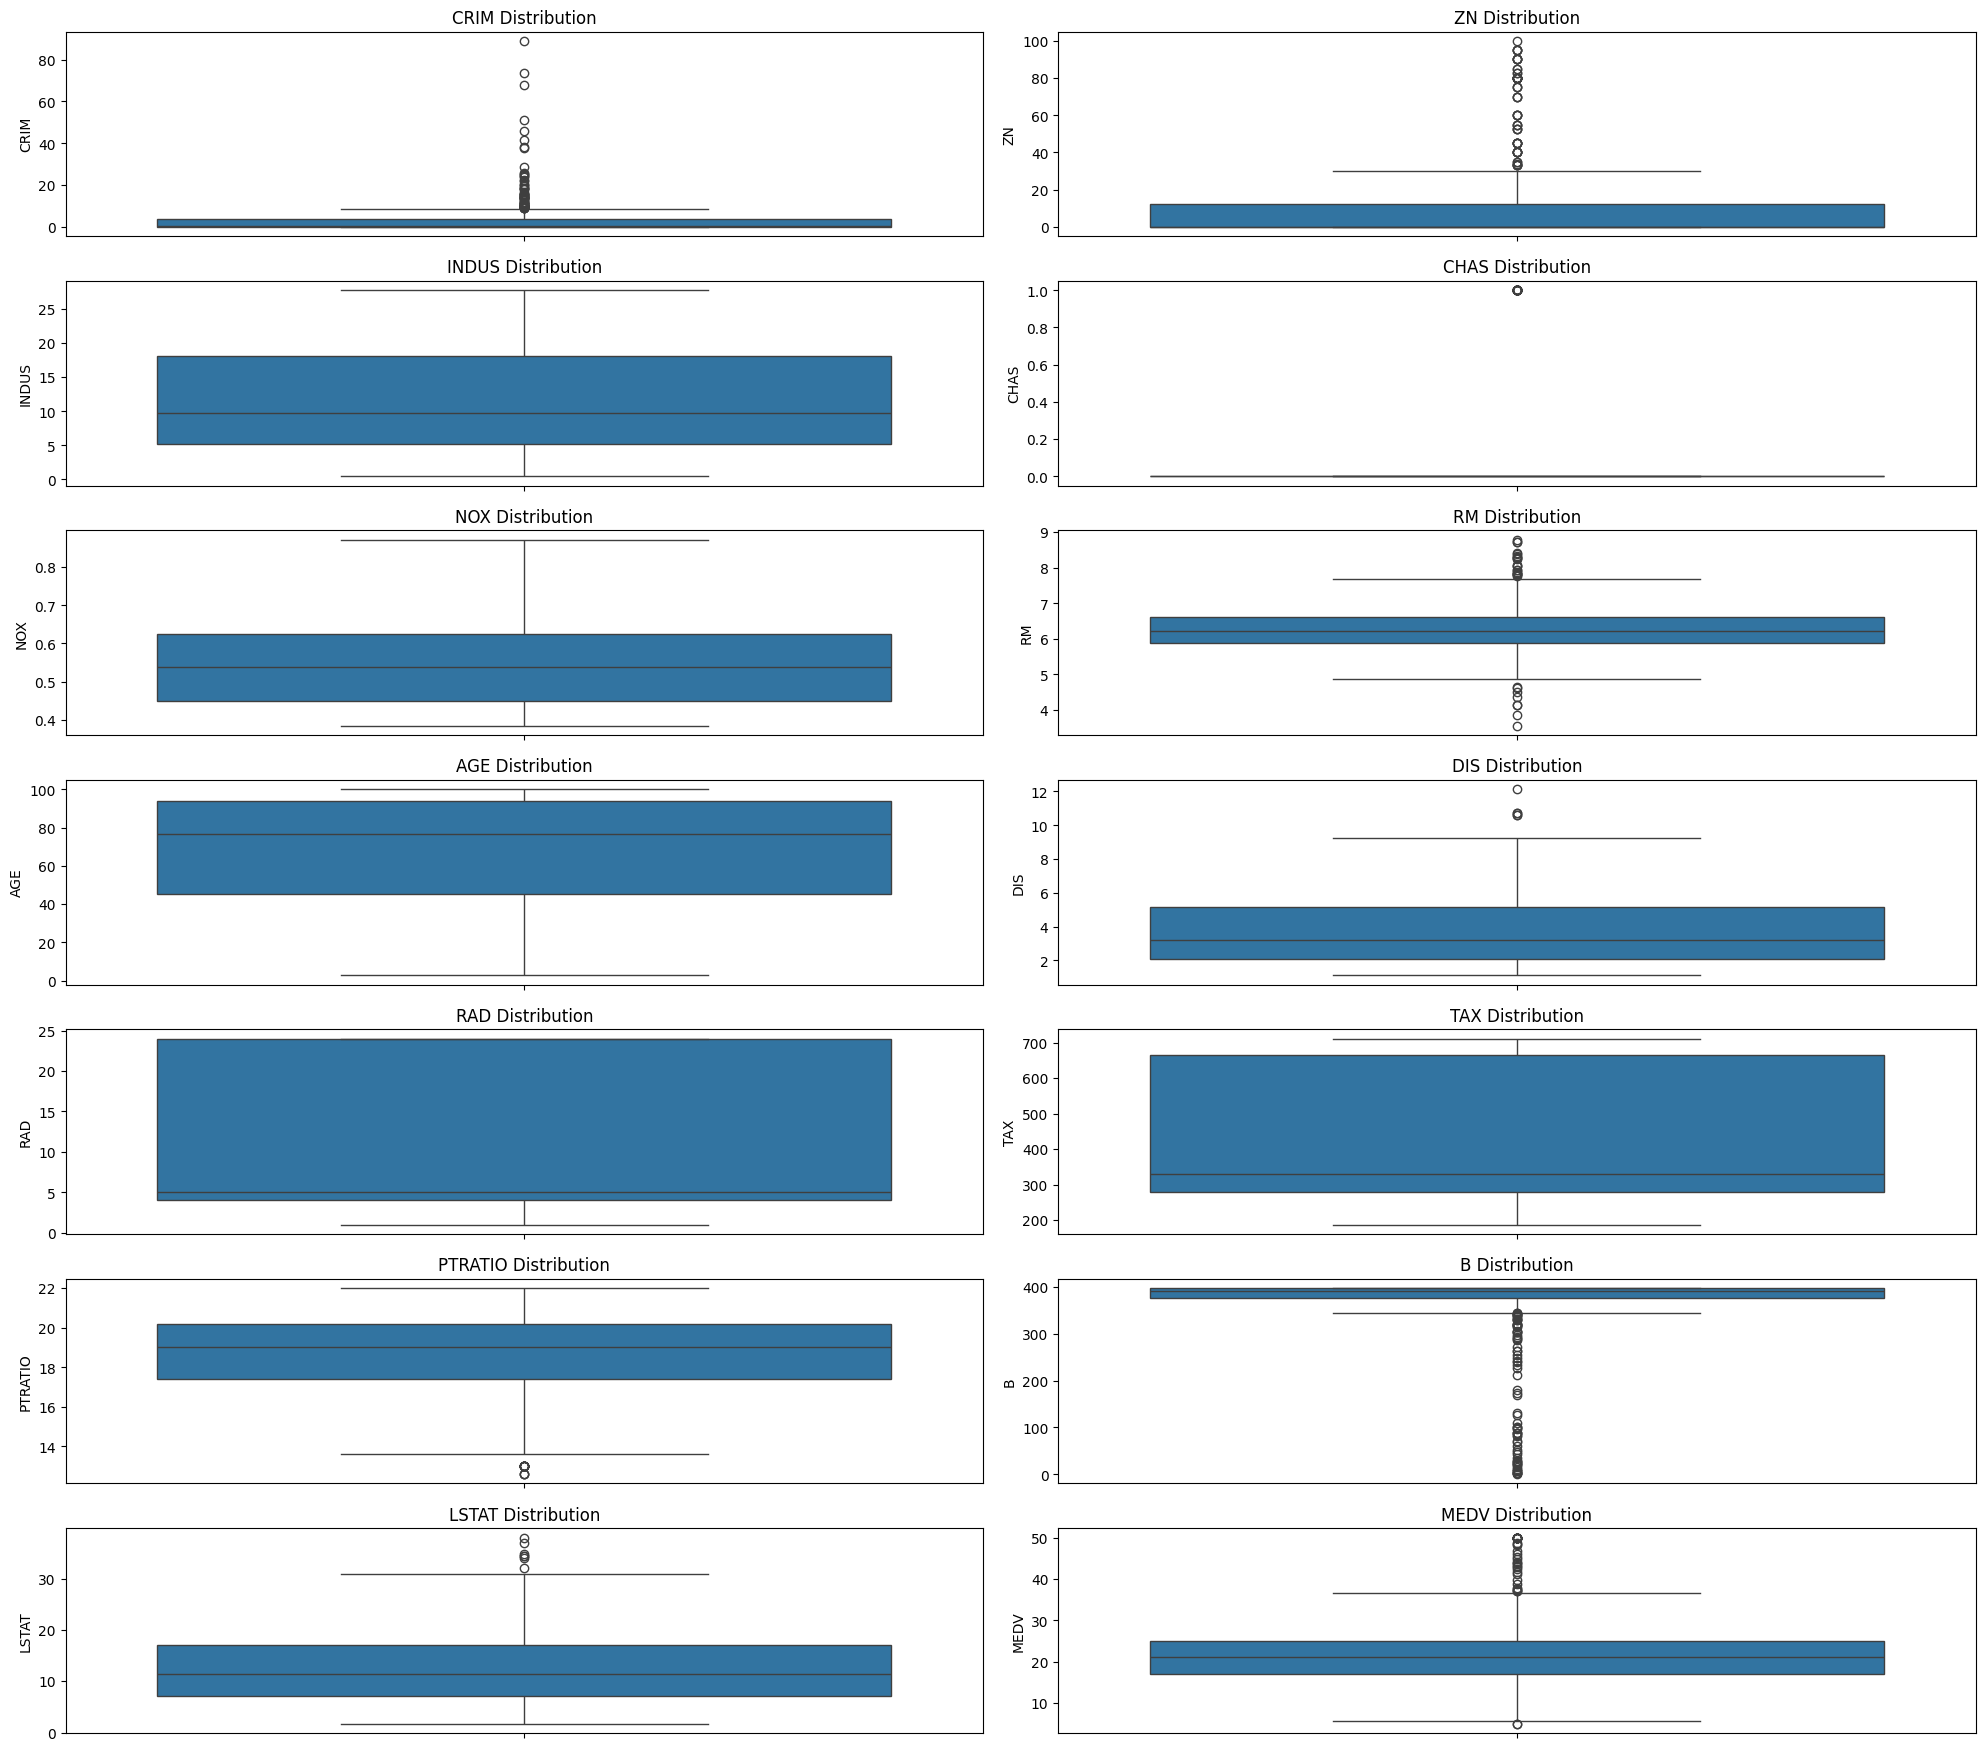

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
x=1
plt.figure(figsize=(20,35))
for i in cols:
    plt.subplot(14,2,x)
    sns.boxplot(df[i])
    plt.title(F"{i} Distribution")
    x+=1
plt.tight_layout()
plt.show()

In [16]:
def handle_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        if IQR == 0:
            print(f"Skipping column with no variance: {col}")
            continue
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else (upper_bound if x > upper_bound else x))
    return df


In [17]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X = df.drop(columns='MEDV')
X_scaled=scaler.fit_transform(X)
y=df['MEDV']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Validation set size: {X_val.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Training set size: 236
Validation set size: 79
Test set size: 79


In [24]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
class SimpleLinearRegression:
    def __init__(self):
        self.theta = None
    def fit(self, X, y):
        # Add a column of ones to X for the intercept
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        self.theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

    # Make predictions
    def predict(self, X):
        X_b = np.c_[np.ones((X.shape[0], 1)), X]
        return X_b.dot(self.theta)
# Initialize the model
model = SimpleLinearRegression()
# Train the model
model.fit(X_train, y_train)
predictions = model.predict(X_test)
mse = np.mean((predictions - y_test) ** 2)
print(f"Mean Squared Error: {mse}")
r2 = r2_score(y_test, predictions ) # R-squared score
print(f"R-squared: {r2}")

Mean Squared Error: 49.617502264493105
R-squared: 0.5530646878713761
